# Historical field surveys and Brown reconstruction

This notebook retains the original lagoon observations and workbook radar/model
comparison, then adds **recovered archived bed sections** and a **2004 Brown Lagoon
depth surface**. Run from top to bottom in the existing `KGG375_AT3` environment.

**Inputs:** SAC2363 and Brown archives in `Input_Data`, the model
rasters from `04`, and existing map inventories. No network downloads occur.
New reconstruction outputs go to
`Output_Data/processed/geomorphology/field_surveys/reconstruction`, the final cell
also writes a catalogue for the interactive map. Existing field comparison
outputs are regenerated.

**Read these distinctions with the results:**

- Workbook radar depths are proxies. The archived `*bottom.dat` files are the
  authors' interpreted radar envelopes, not additional independent soundings.
- BG35 has a reproducible archive-coordinate artefact. Its registered envelope is
  exported and displayed as **provisional**, excluded from the primary numerical
  bed-comparison summary. Registration recovers its map position; it does not
  repair or re-interpret the radar envelope.
- The lagoon raster interpolates positive depth below the **2004 water surface**.
  Its 10 m cells are an output sampling choice, not a claim of 10 m survey resolution.
  There is no extrapolation to the complete lagoon or modern glacier footprint.
- Historical bed elevations and lagoon depths have different vertical references.
  They are not merged into one absolute-elevation terrain surface.

All settings and source hashes are saved with the outputs. The notebook deliberately
stops at sections and the surveyed lagoon: the available transects do not support a
validated whole-glacier bed or detailed bed-slope/aspect reconstruction.

## Existing comparison: historical field-survey comparison

Historical radar and lagoon bathymetry data were obtained from the Australian Antarctic Data Centre (Allison and Thost, 2010) and mapped in WGS84 / UTM zone 43S. Brown Glacier radar profiles comprised 35 survey locations at BG35 (2000), six at BG20 and eight at BG25 (2004). Missing or zero returns were excluded, and the source-labelled W and E returns were retained separately.

Modelled ice thickness, bed elevation and DEM surface elevation were sampled at the survey locations from the common 50 m grid. Field bed-elevation proxies were calculated by subtracting workbook radar-derived thickness estimates from survey surface elevations. Mean bias (model minus field estimate) and RMSE were calculated by profile and return type. Unique model cells were counted because nearby observations could sample the same cell. Supplied thickness uncertainty was included for context; differences in observation dates and radar interpretation mean this constitutes a historical consistency check.

The 2004 bathymetry comprised 211 Brown Lagoon soundings and 16 available Stephenson Lagoon soundings. Depths were expressed positively below the water surface and mapped as point observations alongside historical glacier outlines.

Dataset citation: Allison and Thost (2010), DOI: 10.4225/15/574BBEA0D74B7

In [1]:
## Use openpyxl's alternative XML parser ##

import os

os.environ["OPENPYXL_LXML"] = "False"

import openpyxl

assert not openpyxl.LXML, "Restart the kernel, then run this cell first."
print("Excel XML parser workaround enabled.")

Excel XML parser workaround enabled.


In [2]:
## Capture a traceback if the kernel crashes ##

import faulthandler
from datetime import datetime
from pathlib import Path

crash_log_path = Path.cwd() / (
    f"field_crash_{datetime.now():%Y%m%d_%H%M%S}.log")

crash_log_handle = crash_log_path.open("w", buffering = 1)
faulthandler.enable(file = crash_log_handle, all_threads = True)

print(f"Crash logging enabled:\n{crash_log_path}")

Crash logging enabled:
c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\field_crash_20261009_232811.log


In [3]:
## Imports, project paths and reconstruction settings ##

from pathlib import Path
import hashlib
import importlib.metadata
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import Normalize
from IPython.display import display, FileLink

import rasterio
from rasterio.transform import rowcol, from_origin
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree, Delaunay
from shapely.geometry import LineString, MultiLineString, Polygon, mapping
from shapely.ops import unary_union

# If imports fail, install missing packages in this notebook's kernel:
# %pip install geopandas rasterio scipy openpyxl matplotlib

project_candidates = [Path.cwd(), *Path.cwd().parents]
project_dir = next((p for p in project_candidates if (
    (p / "Input_Data").is_dir() and (p / "Output_Data").is_dir())), None)
if project_dir is None:
    raise FileNotFoundError("Run inside the project containing Input_Data and Output_Data.")

field_input_dir = project_dir / "Input_Data"
processed_dir = project_dir / "Output_Data" / "processed"
field_output_dir = processed_dir / "geomorphology" / "field_surveys"
reconstruction_dir = field_output_dir / "reconstruction"
map_data_dir = processed_dir / "interactive_map_data"
survey_figure_dir = project_dir / "Figures"
for directory in [field_output_dir, reconstruction_dir, map_data_dir, survey_figure_dir]:
    directory.mkdir(parents = True, exist_ok = True)

field_candidates = sorted({p.parent.parent for p in field_input_dir.rglob(
    "Copy of brown_lagoon.csv") if (p.parent.parent / "ASAC_2363.xml").is_file()})
brown_candidates = sorted({p.parent.parent.parent for p in field_input_dir.rglob(
    "bg35bottom.dat") if (p.parent / "RES.m").is_file()})
if len(field_candidates) != 1 or len(brown_candidates) != 1:
    raise ValueError(
        f"Expected one extracted archive of each kind; ASAC2363={field_candidates}; "
        f"Brown={brown_candidates}. Check for duplicate extracted copies.")
field_dir, brown_dir = field_candidates[0], brown_candidates[0]
res_dir = brown_dir / "Final Results" / "RES"

reconstruction_settings = {
    "crs": "EPSG:32743",
    "bed_vertical_offset_m": 0.0,
    "registration_residual_limit_m": 2.0,
    "registration_scale_tolerance": 0.02,
    "bed_sampling_interval_m": 25.0,
    "bathy_cell_size_m": 10.0,
    "bathy_max_triangle_edge_m": 150.0,
    "bathy_max_nearest_sounding_m": 100.0,
    "bathy_edge_trials_m": [100.0, 150.0, 200.0],
    "bathy_validation_block_m": 100.0,
    "shore_track_max_step_m": 25.0,
    "bathy_water_level_asl_m": None}

# Archived radar Z values are already approximately above sea level.
# Do not apply the historical ellipsoid-minus-40 m conversion again.
survey_crs = reconstruction_settings["crs"]
style_path = processed_dir / "book_figure_style.json"
survey_plot_style = json.loads(style_path.read_text()) if style_path.exists() else {}
survey_plot_style = {k: v for k, v in survey_plot_style.items() if k in plt.rcParams}

def save_survey_figure(fig, stem):
    for extension in ["png", "svg"]:
        fig.savefig(survey_figure_dir / f"{stem}.{extension}",
            dpi = 250, bbox_inches = "tight")

def relative_path(path):
    return Path(path).relative_to(project_dir).as_posix()

print(f"Project: {project_dir}")
print(f"ASAC2363: {relative_path(field_dir)}")
print(f"Brown: {relative_path(brown_dir)}")
print("New outputs:", relative_path(reconstruction_dir))

Project: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026
ASAC2363: Input_Data/ASAC2363_Brown_Stephenson_Field_Data
Brown: Input_Data/2003-04_CampaignData/Brown
New outputs: Output_Data/processed/geomorphology/field_surveys/reconstruction


In [4]:
## Prepare the 2004 lagoon soundings ##

bathy_tables = []

for name in ("Brown", "Stephenson"):
    source_path = (
        field_dir / "Lagoon_bathymetry"
        / f"Copy of {name.lower()}_lagoon.csv")

    data = pd.read_csv(source_path, encoding = "utf-8-sig")
    numeric_columns = ["E", "N", "depth"]

    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric, errors = "raise")

    if (
        not np.isfinite(data[numeric_columns].to_numpy()).all()
        or (data["depth"] >= 0).any()):
        raise ValueError(
            f"Invalid coordinates or depth signs in {source_path.name}.")

    # Retain the original waypoint IDs where supplied.
    data["WP"] = data.get(
        "WP", pd.Series(
            pd.NA, index = data.index, dtype = "Int64")).astype("Int64")

    data["name_1"] = name
    data["survey_year"] = 2004
    data["depth_m"] = -data["depth"]
    data["point_id"] = [
        f"{name}_2004_{number:03d}"
        for number in range(1, len(data) + 1)]

    data["source_csv"] = source_path.name
    data["coverage_note"] = (
        "Partial table; see original survey map"
        if name == "Stephenson" else "Available survey soundings")

    bathy_tables.append(data)

bathy_table = pd.concat(bathy_tables, ignore_index = True)

lagoon_soundings = gpd.GeoDataFrame(
    bathy_table,
    geometry = gpd.points_from_xy(bathy_table["E"], bathy_table["N"]),
    crs = "EPSG:32743")

field_output_dir = (
    project_dir / "Output_Data" / "processed"
    / "geomorphology" / "field_surveys")
field_output_dir.mkdir(parents = True, exist_ok = True)

lagoon_soundings.to_file(
    field_output_dir / "Heard_lagoon_soundings_2004.gpkg",
    layer = "lagoon_soundings_2004", driver = "GPKG", index = False)

map_data_dir = (
    project_dir / "Output_Data" / "processed" / "interactive_map_data")
map_data_dir.mkdir(parents = True, exist_ok = True)

lagoon_soundings.to_crs("EPSG:4326").to_file(
    map_data_dir / "lagoon_soundings_2004.geojson",
    driver = "GeoJSON", index = False)

bathy_summary = lagoon_soundings.groupby("name_1").agg(
    soundings = ("depth_m", "size"),
    deepest_sounding_m = ("depth_m", "max"))

display(bathy_summary)

,soundings,deepest_sounding_m
name_1,,
Brown,211,56.0
Stephenson,16,107.0


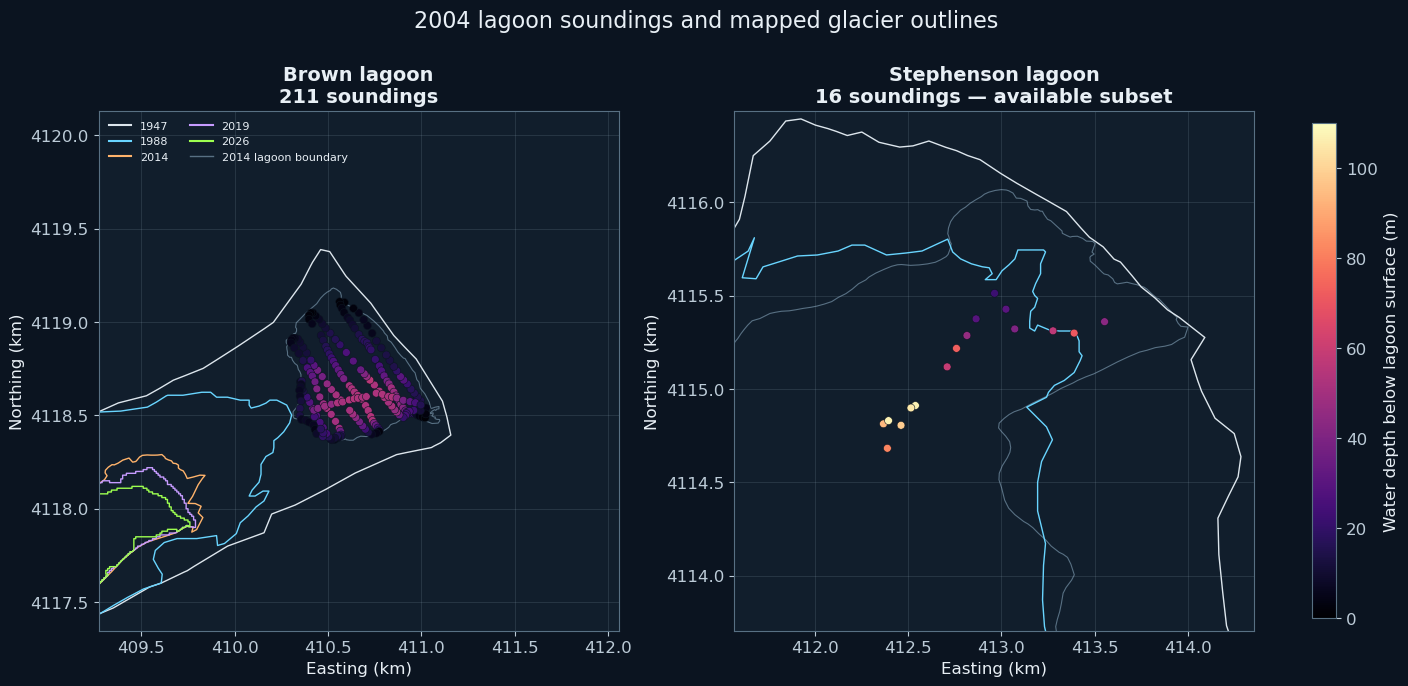

In [5]:
## Compare lagoon soundings and mapped ice margins ##

processed_dir = project_dir / "Output_Data" / "processed"

outline_path = (
    processed_dir / "interactive_map_data" / "glacier_inventories.geojson")

survey_outlines = gpd.read_file(outline_path).to_crs(lagoon_soundings.crs)
survey_outlines["year"] = pd.to_numeric(
    survey_outlines["year"], errors = "raise").astype(int)

lagoon_polygons = gpd.read_file(
    field_input_dir / "heard_island_shp"
    / "UpdatedHI_Lagoons2014.shp").to_crs(lagoon_soundings.crs)

style_path = processed_dir / "book_figure_style.json"
survey_plot_style = (
    json.loads(style_path.read_text()) if style_path.exists() else {})

year_colours = {
    1947: "#DDE6ED",
    1988: "#69D5FF",
    2014: "#FFB36B",
    2019: "#C69BFF",
    2026: "#9DFF50"}

survey_bounds = [
    lagoon_soundings.loc[
        lagoon_soundings["name_1"].eq(name)].total_bounds
    for name in ("Brown", "Stephenson")]

map_span = max(
    max(x2 - x1, y2 - y1)
    for x1, y1, x2, y2 in survey_bounds) + 1600

depth_limit = float(
    np.ceil(lagoon_soundings["depth_m"].max() / 10) * 10)

legend_handles = [
    Line2D([0], [0], color = colour, lw = 1.5, label = str(year))
    for year, colour in year_colours.items()]

legend_handles.append(
    Line2D(
        [0], [0], color = "#587083", lw = 1,
        label = "2014 lagoon boundary"))

with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    lagoon_fig, lagoon_axes = plt.subplots(
        1, 2, figsize = (14, 7), layout = "constrained")

    for ax, name, bounds in zip(
        lagoon_axes, ("Brown", "Stephenson"), survey_bounds):

        points = lagoon_soundings.loc[
            lagoon_soundings["name_1"].eq(name)]

        ice = survey_outlines.loc[
            survey_outlines["name_1"].astype("string")
            .str.strip().str.casefold().eq(name.lower())]

        lagoon_polygons.boundary.plot(
            ax = ax, color = "#587083", linewidth = 0.8, zorder = 1)

        for year, colour in year_colours.items():
            outline = ice.loc[ice["year"].eq(year)]

            if not outline.empty:
                outline.boundary.plot(
                    ax = ax, color = colour, linewidth = 1, zorder = 2)

        depth_artist = ax.scatter(
            points["E"], points["N"], c = points["depth_m"],
            cmap = "magma", vmin = 0, vmax = depth_limit,
            s = 32, edgecolors = "#0B1420",
            linewidths = 0.4, zorder = 3)

        x1, y1, x2, y2 = bounds
        centre_x, centre_y = (x1 + x2) / 2, (y1 + y2) / 2

        qualifier = " — available subset" if name == "Stephenson" else ""

        ax.set(
            title = f"{name} lagoon\n{len(points)} soundings{qualifier}",
            xlim = (centre_x - map_span / 2, centre_x + map_span / 2),
            ylim = (centre_y - map_span / 2, centre_y + map_span / 2),
            xlabel = "Easting (km)", ylabel = "Northing (km)")

        ax.set_aspect("equal")
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value / 1000:.1f}"))
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value / 1000:.1f}"))
        ax.grid(alpha = 0.15)

    lagoon_axes[0].legend(
        handles = legend_handles, loc = "upper left",
        ncol = 2, fontsize = 8)

    lagoon_fig.colorbar(
        depth_artist, ax = lagoon_axes.tolist(),
        label = "Water depth below lagoon surface (m)", shrink = 0.75)

    lagoon_fig.suptitle(
        "2004 lagoon soundings and mapped glacier outlines", fontsize = 16)

    survey_figure_dir = project_dir / "Figures"
    survey_figure_dir.mkdir(parents = True, exist_ok = True)

    for extension in ("png", "svg"):
        lagoon_fig.savefig(
            survey_figure_dir / f"Brown_Stephenson_lagoon_soundings.{extension}",
            dpi = 300, bbox_inches = "tight")

    plt.show()

In [6]:
## Prepare the Brown radar survey locations ##

radar_depth_columns = ["depth_t1_m", "depth_W_m", "depth_E_m"]
radar_tables = []

profile_sources = [
    ("BG35", 2000, "BG35_2000.xlsx", "bg35"),
    ("BG20", 2004, "RES.xlsx", "BG20prof"),
    ("BG25", 2004, "RES.xlsx", "BG25prof")]

for profile, year, filename, sheet in profile_sources:
    raw = pd.read_excel(
        field_dir / "RES" / filename, sheet_name = sheet, header = 1)
    raw.columns = raw.columns.str.strip()

    if profile == "BG35":
        columns = {
            "mid E": "E",
            "mid N": "N",
            "mid Z": "surface_field_m",
            "depth": "depth_t1_m"}
    else:
        columns = {
            "UTM East": "E",
            "UTM North": "N",
            "Elevation": "surface_field_m",
            "depth W": "depth_W_m",
            "depth E": "depth_E_m"}

    data = raw[list(columns)].rename(columns = columns)
    data = data.apply(pd.to_numeric, errors = "coerce")
    data = data.replace([np.inf, -np.inf], np.nan)

    # Zero depth denotes a missing return in these workbooks.
    for column in radar_depth_columns:
        if column not in data:
            data[column] = np.nan

        data[column] = data[column].where(data[column] > 0)

    valid = (
        data[["E", "N", "surface_field_m"]].notna().all(axis = 1)
        & data["E"].gt(0)
        & data["N"].gt(0)
        & data[radar_depth_columns].notna().any(axis = 1))

    data = data.loc[valid].copy()

    # Retain workbook row numbers for tracing each observation.
    data["source_excel_row"] = data.index + 3
    data["profile"] = profile
    data["survey_year"] = year
    data["name_1"] = "Brown"
    data["source_file"] = filename
    data["source_sheet"] = sheet
    data["point_id"] = [
        f"{profile}_{year}_row{row}"
        for row in data["source_excel_row"]]

    data["distance_m"] = np.r_[
        0, np.hypot(np.diff(data["E"]), np.diff(data["N"]))].cumsum()

    radar_tables.append(data)

radar_table = pd.concat(radar_tables, ignore_index = True)

radar_points = gpd.GeoDataFrame(
    radar_table,
    geometry = gpd.points_from_xy(radar_table["E"], radar_table["N"]),
    crs = "EPSG:32743")

display(
    radar_points.groupby(["profile", "survey_year"]).size()
    .rename("survey_locations").to_frame())

,,survey_locations
profile,survey_year,
BG20,2004,6
BG25,2004,8
BG35,2000,35


In [7]:
## Sample the model at radar survey locations ##

def sample_radar_raster(path, points):
    values = np.full(len(points), np.nan)
    cells = pd.Series(pd.NA, index = points.index, dtype = "string")

    with rasterio.open(path) as source:
        projected = points.to_crs(source.crs)
        coordinates = np.column_stack((
            projected.geometry.x.to_numpy(),
            projected.geometry.y.to_numpy()))

        rows, cols = rowcol(
            source.transform, coordinates[:, 0], coordinates[:, 1])
        rows, cols = np.asarray(rows), np.asarray(cols)

        inside = (
            (rows >= 0) & (rows < source.height)
            & (cols >= 0) & (cols < source.width))

        if inside.any():
            samples = np.ma.vstack(list(source.sample(
                coordinates[inside], indexes = 1, masked = True)))

            values[inside] = (
                samples.astype("float64").filled(np.nan)[:, 0]
                * source.scales[0] + source.offsets[0])

            cells.loc[inside] = [
                f"{row}:{col}"
                for row, col in zip(rows[inside], cols[inside])]

    return values, cells

radar_model_dir = (
    project_dir / "Output_Data" / "processed" / "geomorphology")

radar_model_files = {
    "surface": "Heard_surface_DEM_2002_50m.tif",
    "thickness": "Heard_Millan_thickness_land_50m.tif",
    "bed": "Heard_bed_estimate_candidate_50m.tif"}

for label, filename in radar_model_files.items():
    values, cells = sample_radar_raster(
        radar_model_dir / filename, radar_points)

    radar_points[f"model_{label}_m"] = values
    radar_points[f"model_cell_{label}"] = cells

radar_points["model_thickness_m"] = radar_points[
    "model_thickness_m"].where(radar_points["model_thickness_m"] > 0)

radar_points.to_file(
    field_output_dir / "Brown_radar_model_comparison.gpkg",
    layer = "radar_model_comparison", driver = "GPKG", index = False)

In [8]:
## Summarise historical radar and model differences ##

radar_attributes = radar_points.drop(columns = "geometry")

radar_comparison = radar_attributes.melt(
    id_vars = [
        column for column in radar_attributes.columns
        if column not in radar_depth_columns],
    value_vars = radar_depth_columns,
    var_name = "return",
    value_name = "field_depth_proxy_m")

radar_comparison = radar_comparison.dropna(
    subset = ["field_depth_proxy_m"]).copy()

radar_comparison["return"] = radar_comparison["return"].map({
    "depth_t1_m": "t1",
    "depth_W_m": "W",
    "depth_E_m": "E"})

radar_comparison["field_bed_proxy_m"] = (
    radar_comparison["surface_field_m"]
    - radar_comparison["field_depth_proxy_m"])

# Positive differences mean a thicker or higher model estimate.
radar_comparison["H_delta_m"] = (
    radar_comparison["model_thickness_m"]
    - radar_comparison["field_depth_proxy_m"])

radar_comparison["bed_delta_m"] = (
    radar_comparison["model_bed_m"]
    - radar_comparison["field_bed_proxy_m"])

radar_comparison["surface_delta_m"] = (
    radar_comparison["model_surface_m"]
    - radar_comparison["surface_field_m"])

radar_metric_records = []

for (profile, year, echo), group in radar_comparison.groupby(
    ["profile", "survey_year", "return"], sort = False):

    paired = group.loc[
        group[[
            "model_surface_m", "model_thickness_m", "model_bed_m"]]
        .notna().all(axis = 1)]

    radar_metric_records.append({
        "profile": profile,
        "survey_year": year,
        "return": echo,
        "available_returns": len(group),
        "compared": len(paired),
        "model_cells": paired["model_cell_thickness"].nunique(),
        "H_bias_m": paired["H_delta_m"].mean(),
        "H_RMSE_m": np.sqrt(paired["H_delta_m"].pow(2).mean()),
        "bed_bias_m": paired["bed_delta_m"].mean(),
        "bed_RMSE_m": np.sqrt(paired["bed_delta_m"].pow(2).mean()),
        "surface_bias_m": paired["surface_delta_m"].mean()})

radar_metrics = pd.DataFrame(radar_metric_records).sort_values(
    ["survey_year", "profile", "return"])

radar_comparison.to_csv(
    field_output_dir / "Brown_radar_model_return_comparisons.csv",
    index = False)

radar_metrics.to_csv(
    field_output_dir / "Brown_radar_model_metrics.csv", index = False)

display(radar_metrics.round(2))

,profile,survey_year,return,available_returns,compared,model_cells,H_bias_m,H_RMSE_m,bed_bias_m,bed_RMSE_m,surface_bias_m
0,BG35,2000,t1,35,35,21,62.85,88.11,-59.87,83.04,2.98
3,BG20,2004,E,6,6,6,95.16,97.25,-87.40,88.40,7.75
1,BG20,2004,W,5,5,5,86.43,86.65,-82.17,82.56,4.26
4,BG25,2004,E,8,8,8,87.21,91.78,-81.78,91.07,5.43
2,BG25,2004,W,7,7,7,88.56,93.87,-78.30,87.89,10.26


In [9]:
## Check model alignment and sample thickness error ##

radar_error_filename = "Heard_Millan_thickness_error_land_50m.tif"
reference_grid = None

for filename in [
    *radar_model_files.values(), radar_error_filename]:

    with rasterio.open(radar_model_dir / filename) as source:
        grid = (
            source.crs, source.transform, source.width, source.height)

        if reference_grid is None:
            reference_grid = grid
        elif grid != reference_grid:
            raise ValueError(f"Model grid differs: {filename}")

error_values, _ = sample_radar_raster(
    radar_model_dir / radar_error_filename, radar_points)

radar_points["model_thickness_error_m"] = np.where(
    error_values >= 0, error_values, np.nan)

# Check the relationship between the three sampled model layers.
subtraction_difference = (
    radar_comparison["bed_delta_m"]
    - (
        radar_comparison["surface_delta_m"]
        - radar_comparison["H_delta_m"]))

print("All four model raster grids match.")
print(
    "Maximum bed subtraction mismatch: "
    f"{subtraction_difference.abs().max():.6f} m")

display(
    radar_points.groupby("profile").agg(
        survey_locations = ("point_id", "size"),
        model_cells = ("model_cell_thickness", "nunique"),
        locations_with_error = ("model_thickness_error_m", "count"),
        mean_supplied_error_m = ("model_thickness_error_m", "mean"))
    .round(2))

radar_points.to_file(
    field_output_dir / "Brown_radar_model_comparison.gpkg",
    layer = "radar_model_comparison", driver = "GPKG", index = False)

All four model raster grids match.
Maximum bed subtraction mismatch: 0.000031 m


,survey_locations,model_cells,locations_with_error,mean_supplied_error_m
profile,,,,
BG20,6,6,6,51.50
BG25,8,8,8,50.38
BG35,35,21,35,50.11


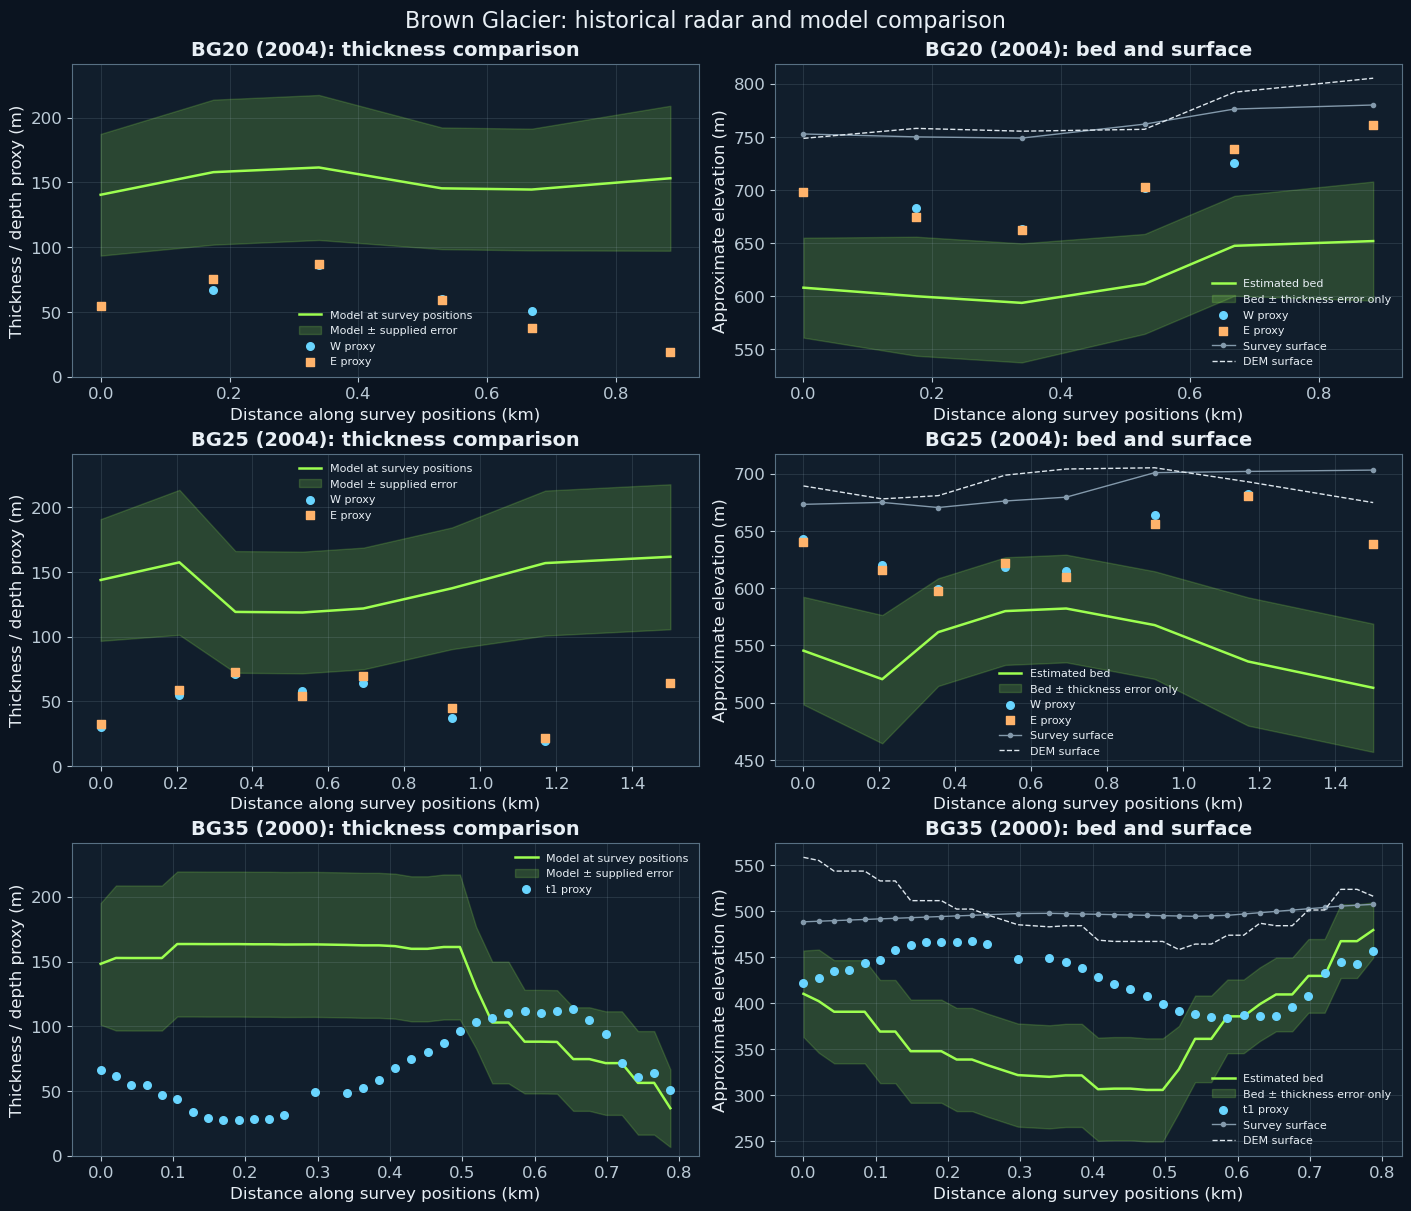

In [10]:
## Compare radar proxies and modelled cross-sections ##

profile_order = [
    ("BG20", 2004),
    ("BG25", 2004),
    ("BG35", 2000)]

return_styles = {
    "depth_t1_m": ("#69D5FF", "o", "t1 proxy"),
    "depth_W_m": ("#69D5FF", "o", "W proxy"),
    "depth_E_m": ("#FFB36B", "s", "E proxy")}

model_colour = "#9DFF50"

thickness_upper = (
    radar_points["model_thickness_m"]
    + radar_points["model_thickness_error_m"].fillna(0))

thickness_limit = max(
    float(thickness_upper.max()),
    float(radar_points[radar_depth_columns].max().max())) * 1.1

with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    radar_fig, radar_axes = plt.subplots(
        3, 2, figsize = (14, 12),
        sharex = "row", layout = "constrained")

    for row, (profile, year) in enumerate(profile_order):
        points = radar_points.loc[
            radar_points["profile"].eq(profile)
            & radar_points["survey_year"].eq(year)
        ].sort_values("distance_m")

        distance = points["distance_m"].to_numpy() / 1000
        model_H = points["model_thickness_m"].to_numpy()
        model_bed = points["model_bed_m"].to_numpy()
        error = points["model_thickness_error_m"].to_numpy()
        field_surface = points["surface_field_m"].to_numpy()

        ax_H, ax_bed = radar_axes[row]

        ax_H.plot(
            distance, model_H, color = model_colour,
            linewidth = 1.8, label = "Model at survey positions")

        ax_bed.plot(
            distance, model_bed, color = model_colour,
            linewidth = 1.8, label = "Estimated bed")

        if np.isfinite(error).any():
            ax_H.fill_between(
                distance, model_H - error, model_H + error,
                color = model_colour, alpha = 0.18,
                label = "Model ± supplied error")

            ax_bed.fill_between(
                distance, model_bed - error, model_bed + error,
                color = model_colour, alpha = 0.18,
                label = "Bed ± thickness error only")

        for column, (colour, marker, label) in return_styles.items():
            depth = points[column].to_numpy()

            if not np.isfinite(depth).any():
                continue

            ax_H.scatter(
                distance, depth, color = colour,
                marker = marker, s = 30, zorder = 3, label = label)

            ax_bed.scatter(
                distance, field_surface - depth,
                color = colour, marker = marker,
                s = 30, zorder = 3, label = label)

        ax_bed.plot(
            distance, field_surface, color = "#8399AB",
            marker = ".", linewidth = 1, label = "Survey surface")

        ax_bed.plot(
            distance, points["model_surface_m"].to_numpy(),
            color = "#DDE6ED", linestyle = "--",
            linewidth = 1, label = "DEM surface")

        ax_H.set(
            title = f"{profile} ({year}): thickness comparison",
            ylabel = "Thickness / depth proxy (m)",
            ylim = (0, thickness_limit))

        ax_bed.set(
            title = f"{profile} ({year}): bed and surface",
            ylabel = "Approximate elevation (m)")

        for ax in (ax_H, ax_bed):
            ax.set_xlabel("Distance along survey positions (km)")
            ax.grid(alpha = 0.15)
            ax.legend(fontsize = 8, loc = "best")

    radar_fig.suptitle(
        "Brown Glacier: historical radar and model comparison",
        fontsize = 16)

    for extension in ("png", "svg"):
        radar_fig.savefig(
            project_dir / "Figures"
            / f"Brown_radar_model_profiles.{extension}",
            dpi = 300, bbox_inches = "tight")

    plt.show()

### Interpreting the workbook comparison

The preceding tables reproduce the existing comparison. The notebook previously
reported model thicknesses roughly 63–95 m greater than the workbook proxies;
use the rerun tables for the current values. Bed and thickness residuals are linked
by surface minus thickness. Survey dates, radar reflection geometry and the DEM's
vertical reference limit interpretation as an accuracy assessment.

The recovered envelopes below provide a separate comparison. Dense digitised
vertices are not independent field observations. BG20/BG25 remain workbook proxies:
this archive provides their plotted envelopes in the report, but no equivalent
digitised bed files. Do not combine them with the archived 2000 envelopes as though
they had identical processing.

## Recover the 2000 interpreted bed sections

`RES.m` defines `*.res` columns as along-profile midpoint, surface elevation and
ellipse semi-axes. `*bottom.dat` stores the interpreted bed in that same section
frame. We register saved midpoint distances against the original UTM antenna
midpoints using a two-coordinate affine fit. The original horizontal coordinate is
retained as `archive_chainage_m`; map distances are stored separately.

**Archive audit:** the supplied BG35 `*.dat` uses zero receiver coordinates for
margin rows. The supplied MATLAB code includes them when fitting the profile line.
Reproducing that calculation matches the saved `*.res` distances, but produces a
registered map length approximately 13.8% greater than its archive length
(map/archive scale ≈1.138). This affects the processing geometry, not just a plot
label. We retain the authored envelope as provisional and do not claim to have
corrected its elevations. BG30, BG45 and BG50 have near-unit registration scales.

The archived radar elevations are treated as approximate heights above sea level,
with **zero additional offset**. A check against nearby ellipsoidal GPS heights
should show differences around 40 m, consistent with the documented field
conversion. This is a datum consistency check, not a geoid transformation or a
measurement-error estimate.

In [11]:
## Recover profile coordinates and audit the legacy geometry ##

recovered_tables = []
registration_records = []
datum_records = []
profile_controls = {}
profile_geometry = {}
static_gps = np.loadtxt(brown_dir / "Final Results" / "DEM" / "brownpoints.dat")
gps_tree = cKDTree(static_gps[:, :2])

for profile in ["BG30", "BG35", "BG45", "BG50"]:
    stem = profile.lower()
    raw = np.loadtxt(res_dir / f"{stem}.dat", ndmin = 2)
    reduced = np.loadtxt(res_dir / f"{stem}.res", ndmin = 2)
    bottom = np.loadtxt(res_dir / f"{stem}bottom.dat", ndmin = 2)
    if raw.shape[1] != 9 or reduced.shape != (len(raw), 8) or bottom.shape[1] != 2:
        raise ValueError(f"Unexpected archive structure: {profile}")
    if not all(np.isfinite(a).all() for a in [raw, reduced, bottom]):
        raise ValueError(f"Non-finite archive values: {profile}")

    valid_pair = ((raw[:, :2] > 0).all(axis = 1)
        & (raw[:, 3:5] > 0).all(axis = 1) & (raw[:, 6:9] > 0).any(axis = 1))
    if valid_pair.sum() < 2:
        raise ValueError(f"Fewer than two registration controls: {profile}")
    midpoint = (raw[valid_pair, :2] + raw[valid_pair, 3:5]) / 2
    chainage = reduced[valid_pair, 0]
    design = np.column_stack([np.ones(len(chainage)), chainage])
    coefficients = np.linalg.lstsq(design, midpoint, rcond = None)[0]
    origin, vector = coefficients
    scale = np.linalg.norm(vector)
    residual = np.linalg.norm(design @ coefficients - midpoint, axis = 1)
    if residual.max() > reconstruction_settings["registration_residual_limit_m"]:
        raise ValueError(f"Poor coordinate registration: {profile}; inspect source rows.")
    np.testing.assert_allclose(reduced[valid_pair, 1],
        (raw[valid_pair, 2] + raw[valid_pair, 5]) / 2, atol = 1e-4, rtol = 0)

    # Reproduce the saved horizontal projection, including placeholder coordinates.
    all_xy = np.vstack([raw[:, :2], raw[:, 3:5]])
    centre = all_xy.mean(axis = 0)
    _, _, basis = np.linalg.svd(all_xy - centre, full_matrices = False)
    projected = centre + ((all_xy - centre) @ basis[0])[:, None] * basis[0]
    distances = np.linalg.norm(projected - projected[0], axis = 1)
    legacy_midpoint = (distances[:len(raw)] + distances[len(raw):]) / 2
    legacy_mismatch = np.max(np.abs(legacy_midpoint[valid_pair] - chainage))
    if legacy_mismatch > 0.05:
        raise ValueError(f"Saved RES distances cannot be reproduced: {profile}")

    geometry_flag = abs(scale - 1) > reconstruction_settings["registration_scale_tolerance"]
    status = "provisional_archive_geometry" if geometry_flag else "registered_archive_section"
    if geometry_flag:
        warnings.warn(f"{profile}: map/archive scale = {scale:.3f}; "
            "registered envelope is provisional and excluded from primary metrics.")

    xyz = np.vstack([raw[:, :3], raw[:, 3:6]])
    xyz = np.unique(xyz[(xyz[:, :2] > 0).all(axis = 1)], axis = 0)
    antenna_chainage = (xyz[:, :2] - origin) @ vector / scale**2
    surface = pd.DataFrame({"archive_chainage_m": antenna_chainage,
        "surface_asl_m": xyz[:, 2]}).groupby("archive_chainage_m", as_index = False).mean()
    surface = surface.sort_values("archive_chainage_m")
    profile_controls[profile] = surface
    profile_geometry[profile] = {"origin": origin, "vector": vector, "scale": scale}

    bottom = bottom[np.argsort(bottom[:, 0])]
    if (np.diff(bottom[:, 0]) <= 0).any():
        raise ValueError(f"Duplicate/reversed bed chainage: {profile}")
    coordinates = origin + bottom[:, :1] * vector
    surface_z = np.interp(bottom[:, 0], surface["archive_chainage_m"],
        surface["surface_asl_m"], left = np.nan, right = np.nan)
    bed_z = bottom[:, 1] + reconstruction_settings["bed_vertical_offset_m"]
    recovered_tables.append(pd.DataFrame({
        "profile": profile, "survey_year": 2000, "name_1": "Brown",
        "RGIId": "RGI60-19.00023", "vertex": np.arange(1, len(bottom) + 1),
        "archive_chainage_m": bottom[:, 0], "E": coordinates[:, 0],
        "N": coordinates[:, 1], "bed_asl_m": bed_z,
        "surface_interp_asl_m": surface_z, "thickness_proxy_m": surface_z - bed_z,
        "map_chainage_m": bottom[:, 0] * scale,
        "distance_from_section_start_m": (bottom[:, 0] - bottom[0, 0]) * scale,
        "registration_extrapolated": (bottom[:, 0] < chainage.min())
            | (bottom[:, 0] > chainage.max()),
        "geometry_status": status, "use_primary_metrics": not geometry_flag,
        "source": relative_path(res_dir / f"{stem}bottom.dat")}))

    gps_distance, gps_index = gps_tree.query(xyz[:, :2])
    for j in np.flatnonzero(gps_distance <= 10):
        datum_records.append({"profile": profile, "E": xyz[j, 0], "N": xyz[j, 1],
            "nearest_static_gps_m": gps_distance[j],
            "gps_ellipsoid_minus_radar_surface_m": static_gps[gps_index[j], 2] - xyz[j, 2]})
    registration_records.append({"profile": profile, "bed_vertices": len(bottom),
        "radar_controls": int(valid_pair.sum()), "map_archive_scale": scale,
        "registration_rmse_m": np.sqrt(np.mean(residual**2)),
        "registration_max_residual_m": residual.max(),
        "saved_chainage_reproduction_error_m": legacy_mismatch,
        "placeholder_antennas": int((all_xy == 0).all(axis = 1).sum()),
        "section_length_m": np.ptp(bottom[:, 0]) * scale,
        "geometry_status": status, "use_primary_metrics": not geometry_flag})

bed_table = pd.concat(recovered_tables, ignore_index = True)
bed_vertices = gpd.GeoDataFrame(bed_table,
    geometry = gpd.points_from_xy(bed_table.E, bed_table.N, bed_table.bed_asl_m),
    crs = survey_crs)
registration_audit = pd.DataFrame(registration_records)
datum_audit = pd.DataFrame(datum_records)
if datum_audit.empty:
    raise ValueError("No nearby GPS controls for the radar datum check.")
datum_summary = datum_audit.groupby("profile").agg(
    nearby_antennas = ("nearest_static_gps_m", "size"),
    median_ellipsoid_minus_radar_m = ("gps_ellipsoid_minus_radar_surface_m", "median"))
if not datum_summary["median_ellipsoid_minus_radar_m"].between(30, 50).all():
    raise ValueError("Unexpected radar vertical reference; inspect datum_audit before continuing.")

registration_audit.to_csv(reconstruction_dir / "Brown_radar_registration_audit.csv", index = False)
datum_audit.to_csv(reconstruction_dir / "Brown_radar_vertical_reference_check.csv", index = False)
display(registration_audit.round(4))
display(datum_summary.round(2))
print("Small registration residuals show coordinate consistency, not bed accuracy.")

C:\Users\harry\AppData\Local\Temp\ipykernel_31072\4077876869.py:51: UserWarning: BG35: map/archive scale = 1.138; registered envelope is provisional and excluded from primary metrics.
  warnings.warn(f"{profile}: map/archive scale = {scale:.3f}; "


,profile,bed_vertices,radar_controls,map_archive_scale,registration_rmse_m,registration_max_residual_m,saved_chainage_reproduction_error_m,placeholder_antennas,section_length_m,geometry_status,use_primary_metrics
0,BG30,4,2,1.0000,0.0000,0.0000,0.0,0,55.9069,registered_archive_section,True
1,BG35,45,35,1.1379,0.0538,0.0986,0.0,2,1012.8124,provisional_archive_geometry,False
2,BG45,5,3,1.0000,0.0002,0.0003,0.0,0,98.9401,registered_archive_section,True
3,BG50,8,4,1.0000,0.0088,0.0128,0.0,0,115.5279,registered_archive_section,True


,nearby_antennas,median_ellipsoid_minus_radar_m
profile,,
BG30,1,39.99
BG35,5,40.50
BG45,1,40.52
BG50,1,41.42


Small registration residuals show coordinate consistency, not bed accuracy.


In [12]:
## Resample interpreted sections and compare with the model grid ##

section_samples = []
for profile, vertices in bed_vertices.groupby("profile", sort = False):
    geometry = profile_geometry[profile]
    s0, s1 = vertices["archive_chainage_m"].agg(["min", "max"])
    length = (s1 - s0) * geometry["scale"]
    count = max(2, int(np.ceil(length / reconstruction_settings["bed_sampling_interval_m"])) + 1)
    local_s = np.linspace(s0, s1, count)
    xy = geometry["origin"] + local_s[:, None] * geometry["vector"]
    controls = profile_controls[profile]
    section_samples.append(pd.DataFrame({"profile": profile, "E": xy[:, 0], "N": xy[:, 1],
        "archive_chainage_m": local_s,
        "distance_m": (local_s - s0) * geometry["scale"],
        "bed_asl_m": np.interp(local_s, vertices.archive_chainage_m, vertices.bed_asl_m),
        "surface_asl_m": np.interp(local_s, controls.archive_chainage_m,
            controls.surface_asl_m, left = np.nan, right = np.nan),
        "use_primary_metrics": bool(vertices.use_primary_metrics.iloc[0]),
        "geometry_status": vertices.geometry_status.iloc[0]}))
section_samples = pd.concat(section_samples, ignore_index = True)
section_samples = gpd.GeoDataFrame(section_samples,
    geometry = gpd.points_from_xy(section_samples.E, section_samples.N), crs = survey_crs)
for label in ["bed", "surface", "thickness"]:
    values, ids = sample_radar_raster(radar_model_dir / radar_model_files[label], section_samples)
    section_samples[f"model_{label}_m"] = values
    section_samples[f"model_cell_{label}"] = ids
section_samples["bed_difference_m"] = section_samples.model_bed_m - section_samples.bed_asl_m

# Give each sampled model cell one contribution, rather than each digitised vertex.
paired = section_samples.dropna(subset = ["model_bed_m", "model_cell_bed"])
cell_comparison = paired.groupby(["profile", "model_cell_bed"], as_index = False).agg(
    model_bed_m = ("model_bed_m", "first"), field_bed_m = ("bed_asl_m", "median"),
    use_primary_metrics = ("use_primary_metrics", "first"),
    geometry_status = ("geometry_status", "first"), sampled_positions = ("bed_asl_m", "size"))
cell_comparison["bed_difference_m"] = cell_comparison.model_bed_m - cell_comparison.field_bed_m
metrics = []
for profile in registration_audit.profile:
    rows = cell_comparison.loc[cell_comparison.profile.eq(profile)]
    residual = rows.bed_difference_m.to_numpy()
    audit = registration_audit.set_index("profile").loc[profile]
    metrics.append({"profile": profile, "model_cells": len(rows),
        "bed_bias_m": np.mean(residual) if len(rows) else np.nan,
        "bed_MAE_m": np.mean(abs(residual)) if len(rows) else np.nan,
        "bed_RMSE_m": np.sqrt(np.mean(residual**2)) if len(rows) else np.nan,
        "geometry_status": audit.geometry_status,
        "use_primary_metrics": bool(audit.use_primary_metrics)})
interpreted_metrics = pd.DataFrame(metrics)
interpreted_metrics.to_csv(reconstruction_dir / "Brown_interpreted_bed_metrics_all.csv", index = False)
interpreted_metrics.loc[interpreted_metrics.use_primary_metrics].to_csv(
    reconstruction_dir / "Brown_interpreted_bed_metrics_primary.csv", index = False)
cell_comparison.to_csv(reconstruction_dir / "Brown_interpreted_bed_model_cells.csv", index = False)
section_samples.drop(columns = "geometry").to_csv(
    reconstruction_dir / "Brown_interpreted_bed_samples.csv", index = False)

bed_lines = []
for profile, vertices in bed_vertices.groupby("profile", sort = False):
    bed_lines.append({"profile": profile, "survey_year": 2000,
        "name_1": "Brown", "RGIId": "RGI60-19.00023",
        "vertical_reference": "approximate metres above sea level; original field convention",
        "geometry_status": vertices.geometry_status.iloc[0],
        "use_primary_metrics": bool(vertices.use_primary_metrics.iloc[0]),
        "geometry": LineString(vertices[["E", "N", "bed_asl_m"]].to_numpy())})
bed_lines = gpd.GeoDataFrame(bed_lines, crs = survey_crs)
bed_gpkg = reconstruction_dir / "Brown_interpreted_bed_2000.gpkg"
for layer_name, data in [("bed_vertices", bed_vertices), ("bed_sections", bed_lines),
        ("comparison_samples", section_samples)]:
    data.to_file(bed_gpkg, layer = layer_name, driver = "GPKG", index = False)
bed_lines.to_crs("EPSG:4326").to_file(
    map_data_dir / "Brown_interpreted_bed_2000.geojson", driver = "GeoJSON", index = False)
display(interpreted_metrics.round(2))
print("Positive bias = model bed is higher. BG35 rows are descriptive only.")

,profile,model_cells,bed_bias_m,bed_MAE_m,bed_RMSE_m,geometry_status,use_primary_metrics
0,BG30,2,-61.78,61.78,62.07,registered_archive_section,True
1,BG35,24,-26.70,53.06,66.75,provisional_archive_geometry,False
2,BG45,2,-24.89,24.89,25.54,registered_archive_section,True
3,BG50,3,6.29,7.82,10.46,registered_archive_section,True


Positive bias = model bed is higher. BG35 rows are descriptive only.


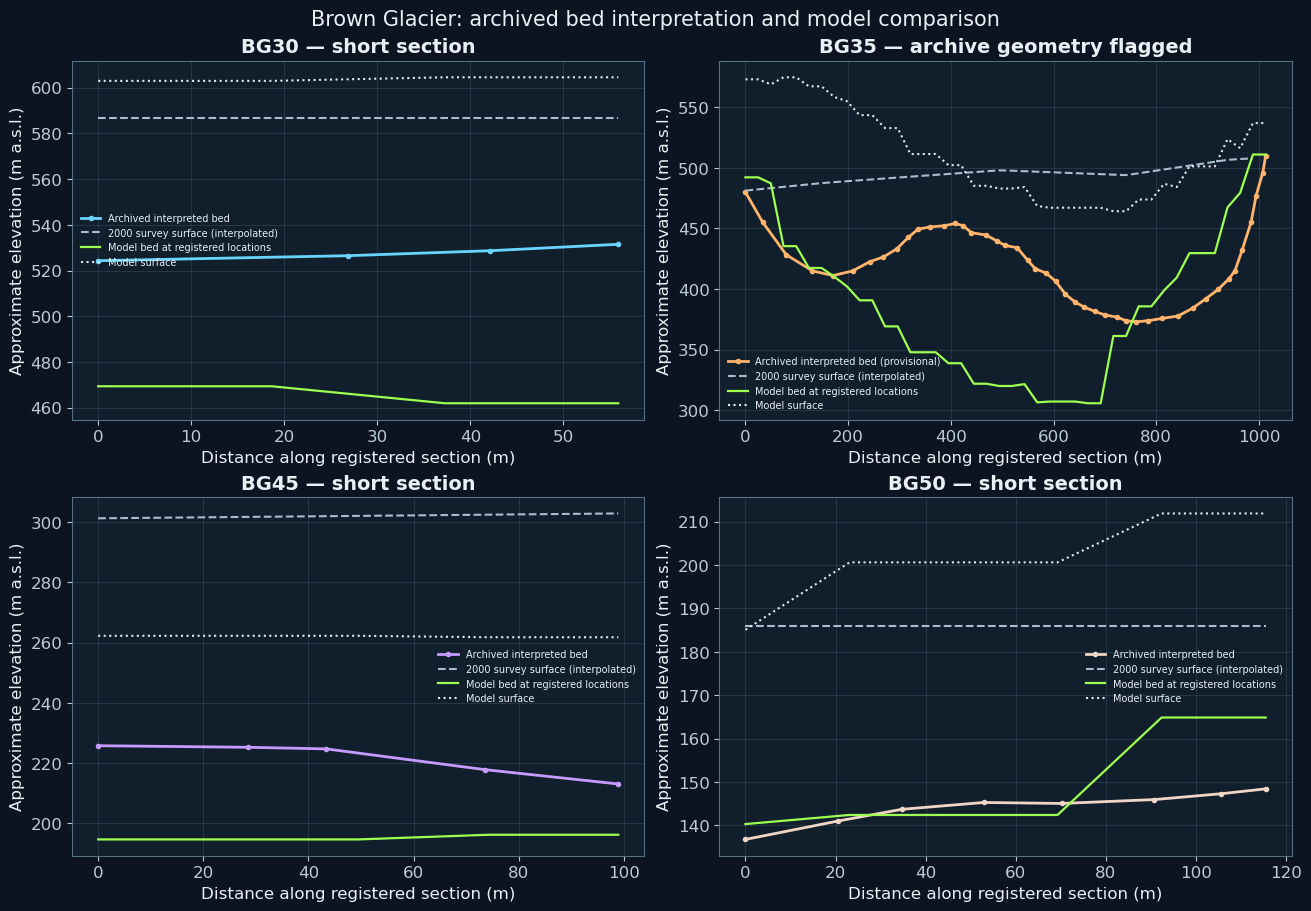

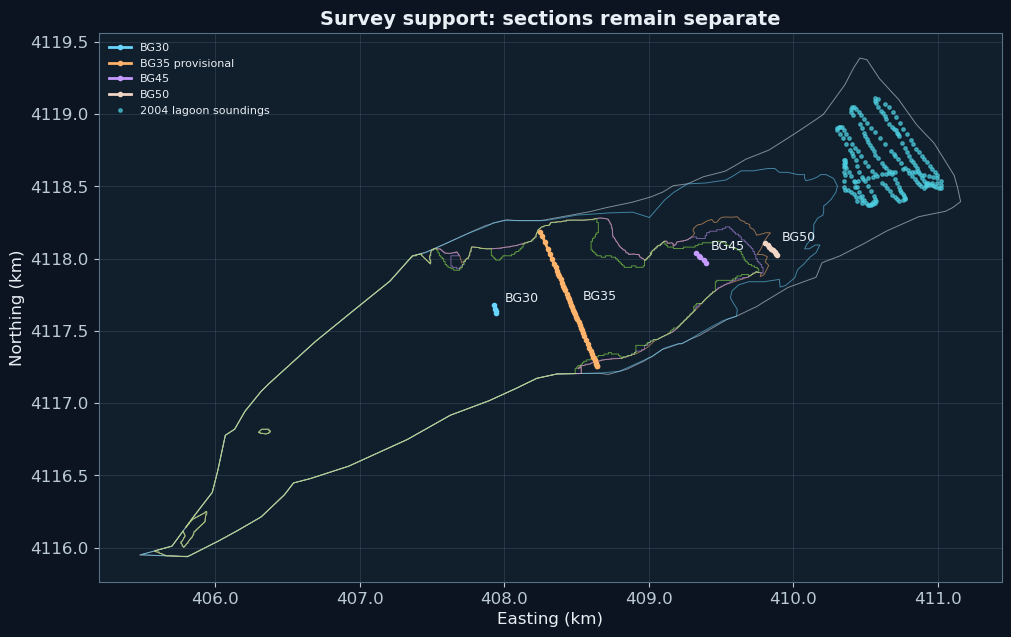

In [13]:
## Plot the recovered sections and survey support ##

profile_colours = {"BG30": "#69D5FF", "BG35": "#FFB36B", "BG45": "#C69BFF", "BG50": "#F1D6C5"}
with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    fig, axes = plt.subplots(2, 2, figsize = (13, 9), layout = "constrained")
    for ax, profile in zip(axes.flat, profile_colours):
        vertices = bed_vertices.loc[bed_vertices.profile.eq(profile)]
        samples = section_samples.loc[section_samples.profile.eq(profile)]
        provisional = not bool(vertices.use_primary_metrics.iloc[0])
        ax.plot(vertices.distance_from_section_start_m, vertices.bed_asl_m,
            color = profile_colours[profile], marker = ".", linewidth = 2,
            label = "Archived interpreted bed" + (" (provisional)" if provisional else ""))
        ax.plot(samples.distance_m, samples.surface_asl_m, color = "#A8BDCD",
            linestyle = "--", label = "2000 survey surface (interpolated)")
        ax.plot(samples.distance_m, samples.model_bed_m, color = "#9DFF50",
            linewidth = 1.6, label = "Model bed at registered locations")
        ax.plot(samples.distance_m, samples.model_surface_m, color = "#E2E8F0",
            linestyle = ":", label = "Model surface")
        ax.set(title = profile + (" — archive geometry flagged" if provisional else " — short section"),
            xlabel = "Distance along registered section (m)", ylabel = "Approximate elevation (m a.s.l.)")
        ax.grid(alpha = 0.15)
        ax.legend(fontsize = 7, loc = "best")
    fig.suptitle("Brown Glacier: archived bed interpretation and model comparison", fontsize = 15)
    save_survey_figure(fig, "06_Brown_interpreted_bed_sections")
    plt.show()

    fig, ax = plt.subplots(figsize = (10, 7), layout = "constrained")
    brown_ice = survey_outlines.loc[survey_outlines.name_1.astype(str).str.casefold().eq("brown")]
    for year, colour in year_colours.items():
        outlines = brown_ice.loc[brown_ice.year.eq(year)]
        if not outlines.empty:
            outlines.boundary.plot(ax = ax, color = colour, linewidth = 0.7, alpha = 0.55)
    for profile, vertices in bed_vertices.groupby("profile", sort = False):
        ax.plot(vertices.E, vertices.N, color = profile_colours[profile],
            marker = ".", linewidth = 2, label = profile + (" provisional" if profile == "BG35" else ""))
        ax.annotate(profile, (vertices.E.mean(), vertices.N.mean()),
            xytext = (7, 6), textcoords = "offset points", fontsize = 9)
    ax.scatter(lagoon_soundings.loc[lagoon_soundings.name_1.eq("Brown"), "E"],
        lagoon_soundings.loc[lagoon_soundings.name_1.eq("Brown"), "N"],
        s = 6, color = "#4DD0E1", alpha = 0.65, label = "2004 lagoon soundings")
    ax.set(aspect = "equal", title = "Survey support: sections remain separate",
        xlabel = "Easting (km)", ylabel = "Northing (km)")
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1000:.1f}"))
    ax.legend(fontsize = 8)
    ax.grid(alpha = 0.15)
    save_survey_figure(fig, "06_Brown_field_coverage")
    plt.show()

## Interpolate the 2004 Brown Lagoon soundings

Use only the 211 measured 2004 depths. The 20 soundings from 2000 are retained as
a separate historical layer; no temporal mixing or apparent-change calculation is
performed. The December 2003 shoreline survey is an **open track**, with occasional
walking deviations and gaps. Short consecutive segments are shown as context and
used as a conservative barrier to triangles that cross that surveyed margin. The
track is not closed into a lagoon polygon or assigned artificial zero-depth values.

The primary surface is a linear Delaunay interpolation. Triangles with edges over
150 m or crossing the retained shoreline segments are rejected, and raster cells
over 100 m from a sounding are masked. These are transparent support choices,
tested at 100/150/200 m maximum triangle edge. Output pixels outside this support
are NoData. The inferred boundary of the support is **not the lagoon shoreline**.

Validation holds out all soundings in each occupied 100 m spatial block. Each
fold rebuilds the triangulation without those depths. Unsupported test points are
reported separately; they are not extrapolated or treated as zero error. Errors
describe prediction within the held-out supported subset, not a full-lagoon
confidence interval or a test of sounder calibration.

In [14]:
## Prepare the lagoon points and contemporaneous shoreline context ##

brown_bathy = lagoon_soundings.loc[lagoon_soundings.name_1.eq("Brown")].copy()
if brown_bathy.duplicated(["E", "N"]).any():
    raise ValueError("Duplicate sounding coordinates require inspection before interpolation.")
bathy_xy = brown_bathy[["E", "N"]].to_numpy(dtype = float)
bathy_depth = brown_bathy.depth_m.to_numpy(dtype = float)
bathy_origin = bathy_xy.mean(axis = 0)

shore_source = field_dir / "Surveys" / "kinematic_surveys.xlsx"
shore = pd.read_excel(shore_source, sheet_name = "lagoon")
shore.columns = shore.columns.str.strip()
shore["source_excel_row"] = np.arange(len(shore)) + 2
shore = shore.rename(columns = {"UTM Easting": "E", "UTM Northing": "N",
    "Height above ellipsoid": "ellipsoid_height_m"})
shore[["E", "N", "ellipsoid_height_m"]] = shore[["E", "N", "ellipsoid_height_m"]].apply(
    pd.to_numeric, errors = "coerce")
shore = shore.dropna(subset = ["E", "N", "ellipsoid_height_m"])
shore = shore.loc[np.isfinite(shore[["E", "N", "ellipsoid_height_m"]]).all(axis = 1)].copy()
shore_xy = shore[["E", "N"]].to_numpy()
steps = np.linalg.norm(np.diff(shore_xy, axis = 0), axis = 1)
consecutive = np.diff(shore.source_excel_row.to_numpy()) == 1
segment_ok = (steps > 0) & (steps <= reconstruction_settings["shore_track_max_step_m"]) & consecutive
shore_segments = [LineString(shore_xy[i:i + 2]) for i in np.flatnonzero(segment_ok)]
if not shore_segments:
    raise ValueError("No usable shoreline segments; inspect the lagoon survey worksheet.")
shore_barrier = unary_union(shore_segments)
shore_lines = gpd.GeoDataFrame({"survey_date": ["2003-12-25"],
    "role": ["partial shoreline survey; no zero-depth constraint"],
    "geometry": [MultiLineString(shore_segments)]}, crs = survey_crs)

bathy_2000 = np.loadtxt(brown_dir / "Final Results" / "Lagoon bathymetry" / "bathy.txt")
historical_bathy = gpd.GeoDataFrame({"E": bathy_2000[:, 0], "N": bathy_2000[:, 1],
    "depth_m": bathy_2000[:, 2], "survey_year": 2000, "name_1": "Brown"},
    geometry = gpd.points_from_xy(bathy_2000[:, 0], bathy_2000[:, 1]), crs = survey_crs)
if not np.isfinite(bathy_2000).all() or (bathy_2000[:, 2] <= 0).any():
    raise ValueError("Unexpected signs or missing values in the 2000 bathymetry.")

nearest_spacing = cKDTree(bathy_xy).query(bathy_xy, k = 2)[0][:, 1]
print(f"2004: {len(brown_bathy)} unique soundings; deepest = {bathy_depth.max():.1f} m")
print(f"Median nearest-neighbour spacing: {np.median(nearest_spacing):.1f} m")
print(f"2000: {len(historical_bathy)} separate soundings; deepest = {historical_bathy.depth_m.max():.1f} m")
print(f"Shoreline track: {len(shore)} positions; endpoint gap = {np.linalg.norm(shore_xy[-1] - shore_xy[0]):.0f} m")

2004: 211 unique soundings; deepest = 56.0 m
Median nearest-neighbour spacing: 21.9 m
2000: 20 separate soundings; deepest = 52.7 m
Shoreline track: 581 positions; endpoint gap = 925 m


In [15]:
## Build a support-limited linear interpolator ##

def make_bathy_interpolator(xy, depths, maximum_edge_m):
    # Centre coordinates for numerical stability without changing metre distances.
    origin = xy.mean(axis = 0)
    triangulation = Delaunay(xy - origin)
    corners = xy[triangulation.simplices]
    maximum_edges = np.linalg.norm(corners - np.roll(corners, 1, axis = 1), axis = 2).max(axis = 1)
    polygons = [Polygon(points) for points in corners]
    crosses_shore = np.array([p.intersects(shore_barrier) for p in polygons])
    accepted_triangles = (maximum_edges <= maximum_edge_m) & ~crosses_shore
    linear = LinearNDInterpolator(triangulation, depths, fill_value = np.nan)
    tree = cKDTree(xy)

    def evaluate(query_xy):
        query_xy = np.asarray(query_xy, dtype = float)
        simplex = triangulation.find_simplex(query_xy - origin)
        nearest = tree.query(query_xy)[0]
        inside = simplex >= 0
        usable = np.zeros(len(query_xy), dtype = bool)
        usable[inside] = accepted_triangles[simplex[inside]]
        usable &= nearest <= reconstruction_settings["bathy_max_nearest_sounding_m"]
        values = np.asarray(linear(query_xy - origin), dtype = float)
        values[~usable] = np.nan
        local_edge = np.full(len(query_xy), np.nan)
        local_edge[inside] = maximum_edges[simplex[inside]]
        return values, nearest, local_edge, usable

    return {"evaluate": evaluate, "triangulation": triangulation,
        "polygons": polygons, "accepted": accepted_triangles,
        "maximum_edges": maximum_edges, "crosses_shore": crosses_shore,
        "origin": origin, "linear": linear}

cell_size = reconstruction_settings["bathy_cell_size_m"]
west, south = np.floor(bathy_xy.min(axis = 0) / cell_size) * cell_size
east, north = np.ceil(bathy_xy.max(axis = 0) / cell_size) * cell_size
bathy_x = np.arange(west + cell_size / 2, east, cell_size)
bathy_y = np.arange(north - cell_size / 2, south, -cell_size)
bathy_X, bathy_Y = np.meshgrid(bathy_x, bathy_y)
query_xy = np.column_stack([bathy_X.ravel(), bathy_Y.ravel()])
bathy_transform = from_origin(west, north, cell_size, cell_size)
bathy_model = make_bathy_interpolator(bathy_xy, bathy_depth,
    reconstruction_settings["bathy_max_triangle_edge_m"])
values, nearest, local_edges, support = bathy_model["evaluate"](query_xy)
bathy_grid = values.reshape(bathy_X.shape)
nearest_grid = nearest.reshape(bathy_X.shape)
edge_grid = local_edges.reshape(bathy_X.shape)
support_grid = support.reshape(bathy_X.shape)
if not support.any():
    raise ValueError("No supported lagoon cells under the selected settings.")
if np.nanmin(bathy_grid) < bathy_depth.min() - 1e-6 or np.nanmax(bathy_grid) > bathy_depth.max() + 1e-6:
    raise ValueError("Linear interpolation overshot its source-depth range.")

# Exact interpolation at input coordinates checks the implementation, not accuracy.
at_source = bathy_model["linear"](bathy_xy - bathy_model["origin"])
np.testing.assert_allclose(at_source, bathy_depth, atol = 1e-6, rtol = 0)
triangle_table = gpd.GeoDataFrame({"triangle_id": np.arange(len(bathy_model["polygons"])),
    "max_edge_m": bathy_model["maximum_edges"], "crosses_surveyed_margin": bathy_model["crosses_shore"],
    "retained": bathy_model["accepted"], "geometry": bathy_model["polygons"]}, crs = survey_crs)

print(f"Supported area: {support.sum() * cell_size**2 / 1e6:.3f} km² (not total lagoon area)")
print(f"Accepted triangles: {bathy_model['accepted'].sum()} / {len(triangle_table)}")
print(f"Triangles touching the surveyed margin: {bathy_model['crosses_shore'].sum()}")
print("Surface range:", round(float(np.nanmin(bathy_grid)), 2), "to", round(float(np.nanmax(bathy_grid)), 2), "m depth")

Supported area: 0.330 km² (not total lagoon area)
Accepted triangles: 380 / 402
Triangles touching the surveyed margin: 2
Surface range: 1.61 to 55.64 m depth


In [16]:
## Validate by spatial blocks and test the support choices ##

block_size = reconstruction_settings["bathy_validation_block_m"]
blocks = np.floor(bathy_xy / block_size).astype(int)
validation_tables = []
sensitivity_records = []

for maximum_edge in reconstruction_settings["bathy_edge_trials_m"]:
    prediction = np.full(len(bathy_depth), np.nan)
    test_nearest = np.full(len(bathy_depth), np.nan)
    for block in np.unique(blocks, axis = 0):
        held_out = (blocks == block).all(axis = 1)
        train = ~held_out
        model = make_bathy_interpolator(bathy_xy[train], bathy_depth[train], maximum_edge)
        prediction[held_out], test_nearest[held_out], _, _ = model["evaluate"](bathy_xy[held_out])
    valid = np.isfinite(prediction)
    residual = prediction[valid] - bathy_depth[valid]
    full_model = make_bathy_interpolator(bathy_xy, bathy_depth, maximum_edge)
    full_values, _, _, full_support = full_model["evaluate"](query_xy)
    common = full_support & support
    difference = full_values[common] - values[common]
    sensitivity_records.append({"maximum_triangle_edge_m": maximum_edge,
        "supported_area_km2": full_support.sum() * cell_size**2 / 1e6,
        "validation_total": len(valid), "validation_supported": int(valid.sum()),
        "validation_supported_percent": 100 * valid.mean(),
        "validation_bias_m": np.mean(residual) if valid.any() else np.nan,
        "validation_MAE_m": np.mean(abs(residual)) if valid.any() else np.nan,
        "validation_RMSE_m": np.sqrt(np.mean(residual**2)) if valid.any() else np.nan,
        "shared_support_max_change_m": np.max(abs(difference)) if len(difference) else np.nan})
    validation_tables.append(pd.DataFrame({"point_id": brown_bathy.point_id.to_numpy(),
        "E": bathy_xy[:, 0], "N": bathy_xy[:, 1], "block_E": blocks[:, 0], "block_N": blocks[:, 1],
        "max_edge_m": maximum_edge, "observed_depth_m": bathy_depth,
        "held_out_prediction_m": prediction, "residual_m": prediction - bathy_depth,
        "supported_prediction": valid, "nearest_training_sounding_m": test_nearest}))

bathy_validation = pd.concat(validation_tables, ignore_index = True)
bathy_sensitivity = pd.DataFrame(sensitivity_records)
bathy_validation.to_csv(reconstruction_dir / "Brown_lagoon_2004_block_predictions.csv", index = False)
bathy_sensitivity.to_csv(reconstruction_dir / "Brown_lagoon_2004_support_sensitivity.csv", index = False)
display(bathy_sensitivity.round(3))
print("Changing the edge limit changes coverage; shared cells use the same linear interpolant.")
print("Compare errors together with held-out coverage; unsupported folds are not scored.")

,maximum_triangle_edge_m,supported_area_km2,validation_total,validation_supported,validation_supported_percent,validation_bias_m,validation_MAE_m,validation_RMSE_m,shared_support_max_change_m
0,100.0,0.200,211,14,6.635,-0.142,0.864,1.405,0.0
1,150.0,0.330,211,119,56.398,-1.948,2.953,4.470,0.0
2,200.0,0.337,211,162,76.777,-1.815,3.128,4.817,0.0


Changing the edge limit changes coverage; shared cells use the same linear interpolant.
Compare errors together with held-out coverage; unsupported folds are not scored.


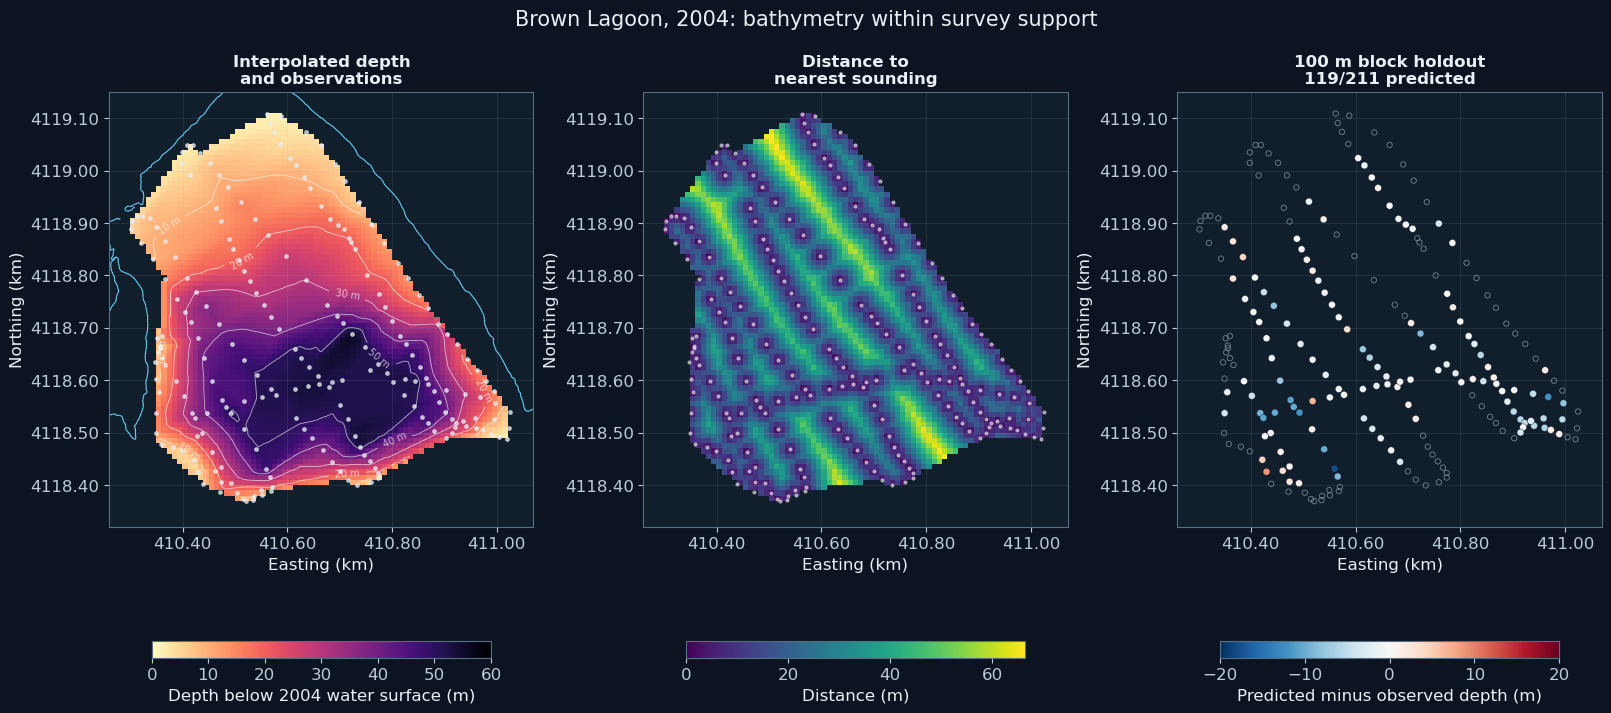

In [17]:
## Plot bathymetry, support and held-out errors ##

primary_validation = bathy_validation.loc[bathy_validation.max_edge_m.eq(
    reconstruction_settings["bathy_max_triangle_edge_m"])]
tested = primary_validation.loc[primary_validation.supported_prediction]
plot_extent = [west, east, south, north]
with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    fig, axes = plt.subplots(1, 3, figsize = (16, 7), layout = "constrained")
    image = axes[0].imshow(bathy_grid, extent = plot_extent, origin = "upper",
        cmap = "magma_r", vmin = 0, vmax = 60, interpolation = "nearest")
    axes[0].scatter(*bathy_xy.T, s = 6, c = "#E7EDF2", alpha = 0.7, label = "2004 soundings")
    shore_lines.plot(ax = axes[0], color = "#69D5FF", linewidth = 0.8,
        label = "December 2003 margin track")
    contour_levels = np.arange(10, 60, 10)
    contours = axes[0].contour(bathy_X, bathy_Y, bathy_grid, levels = contour_levels,
        colors = "#FFFFFF", linewidths = 0.6, alpha = 0.65)
    axes[0].clabel(contours, fontsize = 7, fmt = "%d m")
    axes[0].set_title("Interpolated depth\nand observations", fontsize = 12)
    fig.colorbar(image, ax = axes[0], shrink = 0.8, orientation = "horizontal",
        pad = 0.12, label = "Depth below 2004 water surface (m)")
    distance_image = axes[1].imshow(np.where(support_grid, nearest_grid, np.nan),
        extent = plot_extent, origin = "upper", cmap = "viridis", interpolation = "nearest")
    axes[1].scatter(*bathy_xy.T, s = 4, c = "white", alpha = 0.5)
    axes[1].set_title("Distance to\nnearest sounding", fontsize = 12)
    fig.colorbar(distance_image, ax = axes[1], shrink = 0.8, orientation = "horizontal",
        pad = 0.12, label = "Distance (m)")
    limit = max(5, float(np.ceil(tested.residual_m.abs().max() / 5) * 5)) if len(tested) else 5
    axes[2].scatter(*bathy_xy.T, s = 15, facecolors = "none", edgecolors = "#758394",
        linewidths = 0.6, label = "Unsupported held-out prediction")
    residual_image = axes[2].scatter(tested.E, tested.N, c = tested.residual_m,
        cmap = "RdBu_r", vmin = -limit, vmax = limit, s = 25, edgecolors = "#111827", linewidths = 0.3)
    axes[2].set_title(f"100 m block holdout\n{len(tested)}/{len(brown_bathy)} predicted", fontsize = 12)
    fig.colorbar(residual_image, ax = axes[2], shrink = 0.8, orientation = "horizontal",
        pad = 0.12, label = "Predicted minus observed depth (m)")
    for ax in axes:
        ax.set(aspect = "equal", xlabel = "Easting (km)", ylabel = "Northing (km)",
            xlim = (west - 40, east + 40), ylim = (south - 40, north + 40))
        for axis in [ax.xaxis, ax.yaxis]:
            axis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1000:.2f}"))
        ax.grid(alpha = 0.12)
    fig.suptitle("Brown Lagoon, 2004: bathymetry within survey support", fontsize = 15)
    save_survey_figure(fig, "06_Brown_lagoon_bathymetry_QA")
    plt.show()

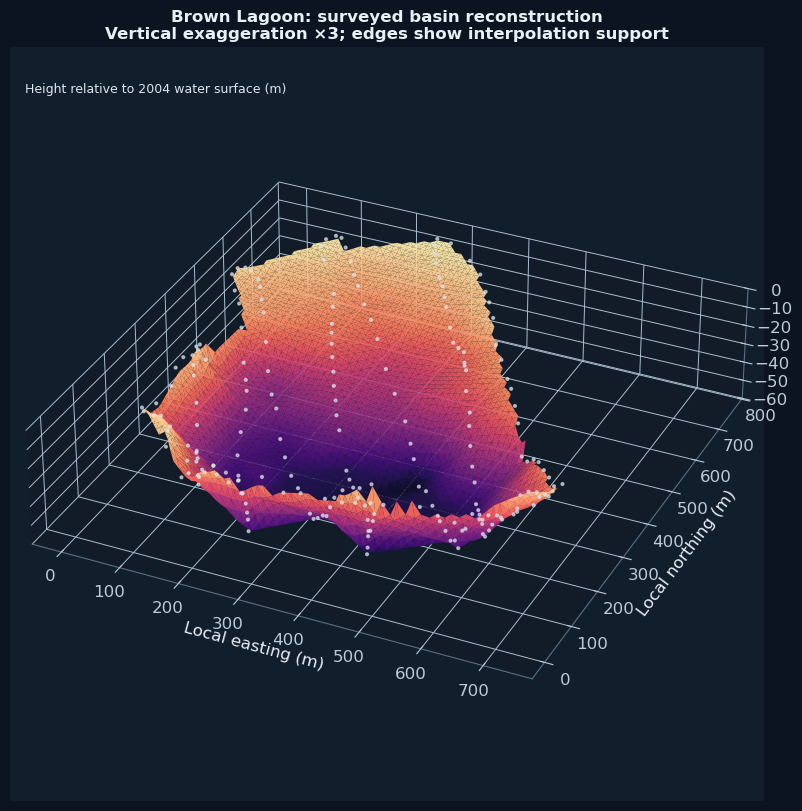

c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Figures\06_Brown_lagoon_3D.html

In [18]:
## Preview the lagoon basin in three dimensions ##

# Triangulate the supported raster centres and require each display triangle
# to lie completely inside the accepted source-triangle footprint.
accepted_footprint = unary_union(triangle_table.loc[triangle_table.retained, "geometry"].tolist())
mesh_xy = query_xy[support]
mesh_z = -values[support]
display_triangles = Delaunay(mesh_xy - bathy_origin).simplices
display_corners = mesh_xy[display_triangles]
display_edges = np.linalg.norm(display_corners - np.roll(display_corners, 1, axis = 1), axis = 2).max(axis = 1)
display_ok = display_edges <= cell_size * 1.5
for i in np.flatnonzero(display_ok):
    display_ok[i] = accepted_footprint.covers(Polygon(display_corners[i]))
mesh_triangles = display_triangles[display_ok]
if not len(mesh_triangles):
    raise ValueError("No supported display triangles; inspect the bathymetry grid.")
mesh = mtri.Triangulation(mesh_xy[:, 0] - west, mesh_xy[:, 1] - south, triangles = mesh_triangles)
vertical_exaggeration = 3

with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    fig = plt.figure(figsize = (11, 8), layout = "constrained")
    ax = fig.add_subplot(111, projection = "3d")
    ax.plot_trisurf(mesh, mesh_z, cmap = "magma", vmin = -60, vmax = 0,
        linewidth = 0, antialiased = True, alpha = 0.95)
    ax.scatter(bathy_xy[:, 0] - west, bathy_xy[:, 1] - south, -bathy_depth,
        s = 4, color = "#DDE6ED", alpha = 0.65)
    ax.set(xlabel = "Local easting (m)", ylabel = "Local northing (m)", zlabel = "")
    ax.set_title("Brown Lagoon: surveyed basin reconstruction\nVertical exaggeration ×3; edges show interpolation support",
        fontsize = 12)
    ax.text2D(0.02, 0.94, "Height relative to 2004 water surface (m)",
        transform = ax.transAxes, fontsize = 9, color = "#DDE6ED")
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((0.07, 0.11, 0.16, 1))
    ax.set_box_aspect((east - west, north - south, 60 * vertical_exaggeration))
    ax.set_zlim(-60, 0)
    ax.view_init(elev = 32, azim = -65)
    save_survey_figure(fig, "06_Brown_lagoon_3D")
    plt.show()

# Save an optional interactive preview without making Plotly a required dependency.
interactive_preview_path = survey_figure_dir / "06_Brown_lagoon_3D.html"
interactive_preview_created = False
try:
    import plotly.graph_objects as go
except ImportError:
    print("Static 3D preview saved. Install plotly only if you also want a rotatable HTML preview.")
else:
    figure3d = go.Figure(go.Mesh3d(x = mesh_xy[:, 0] - west, y = mesh_xy[:, 1] - south,
        z = mesh_z, i = mesh_triangles[:, 0], j = mesh_triangles[:, 1], k = mesh_triangles[:, 2],
        intensity = -mesh_z, colorscale = "Magma", cmin = 0, cmax = 60,
        colorbar = {"title": "Depth (m)"},
        hovertemplate = "Local E: %{x:.0f} m<br>Local N: %{y:.0f} m<br>Relative height: %{z:.1f} m<extra></extra>"))
    figure3d.update_layout(template = "plotly_dark", title = "Brown Lagoon, 2004 — vertical exaggeration ×3",
        scene = {"xaxis_title": "Local easting (m)", "yaxis_title": "Local northing (m)",
            "zaxis_title": "Height relative to water (m)",
            "aspectmode": "manual", "aspectratio": {"x": (east - west) / (north - south),
                "y": 1, "z": 60 * vertical_exaggeration / (north - south)}})
    figure3d.write_html(interactive_preview_path, include_plotlyjs = True, full_html = True)
    interactive_preview_created = True
    display(FileLink(str(interactive_preview_path)))

In [21]:
## Explore Brown Lagoon in interactive 3D ##

import plotly.graph_objects as go

# Match axis proportions to their physical distances.
lagoon_width = float(east - west)
lagoon_length = float(north - south)
lagoon_z_range = 60.0

def lagoon_aspect(exaggeration):
    return dict(x = lagoon_width / lagoon_length, y = 1,
        z = lagoon_z_range * exaggeration / lagoon_length)

lagoon_3d = go.Figure()

lagoon_3d.add_trace(go.Mesh3d(
    x = mesh_xy[:, 0] - west,
    y = mesh_xy[:, 1] - south,
    z = mesh_z,
    i = mesh_triangles[:, 0],
    j = mesh_triangles[:, 1],
    k = mesh_triangles[:, 2],
    intensity = -mesh_z,
    customdata = -mesh_z,
    colorscale = "Magma_r",
    cmin = 0, cmax = 60,
    colorbar = dict(title = "Depth (m)", thickness = 15),
    name = "Interpolated bed",
    showlegend = False,
    hovertemplate = (
        "Local easting: %{x:.0f} m<br>"
        "Local northing: %{y:.0f} m<br>"
        "Depth: %{customdata:.1f} m<extra>Interpolated bed</extra>")))

lagoon_3d.add_trace(go.Scatter3d(
    x = bathy_xy[:, 0] - west,
    y = bathy_xy[:, 1] - south,
    z = -bathy_depth,
    customdata = bathy_depth,
    mode = "markers",
    marker = dict(size = 3, color = "#E7EDF2", opacity = 0.8),
    name = "2004 soundings",
    hovertemplate = "Measured depth: %{customdata:.1f} m<extra>Sounding</extra>"))

lagoon_3d.update_layout(
    template = "plotly_dark",
    title = dict(text = "Brown Lagoon, 2004 — supported bathymetry", x = 0.03),
    height = 750,
    margin = dict(l = 10, r = 20, t = 115, b = 15),
    paper_bgcolor = "#101722",
    legend = dict(x = 0.02, y = 0.98),
    scene = dict(
        bgcolor = "#101722",
        xaxis = dict(title = "Local easting (m)", range = [0, lagoon_width]),
        yaxis = dict(title = "Local northing (m)", range = [0, lagoon_length]),
        zaxis = dict(title = "Height relative to water (m)", range = [-60, 0]),
        aspectmode = "manual",
        aspectratio = lagoon_aspect(3),
        dragmode = "orbit",
        camera = dict(eye = dict(x = 1.4, y = -1.6, z = 1.1))),
    updatemenus = [dict(
        type = "buttons", direction = "right",
        x = 0.02, y = 1.12, xanchor = "left",
        active = 1,
        buttons = [
            dict(label = f"{factor}× vertical", method = "relayout",
                args = [{"scene.aspectratio": lagoon_aspect(factor)}])
            for factor in [1, 3, 5]])])

lagoon_controls = dict(
    scrollZoom = True,
    displaylogo = False,
    toImageButtonOptions = dict(
        filename = "Brown_lagoon_2004_3D", format = "png", scale = 2))

# Save an offline copy alongside the other survey figures.
lagoon_html = survey_figure_dir / "06_Brown_lagoon_3D_interactive.html"
lagoon_3d.write_html(lagoon_html, include_plotlyjs = True, config = lagoon_controls)

lagoon_3d.show(renderer = "vscode", config = lagoon_controls)

In [19]:
## Export bathymetry, contours and the supported display mesh ##

def write_field_raster(array, path, units, description):
    data = np.where(np.isfinite(array), array, -9999).astype("float32")
    with rasterio.open(path, "w", driver = "GTiff", width = len(bathy_x), height = len(bathy_y),
            count = 1, dtype = "float32", crs = survey_crs, transform = bathy_transform,
            nodata = -9999, compress = "deflate") as dst:
        dst.write(data, 1)
        dst.set_band_description(1, description)
        dst.update_tags(units = units, survey_year = "2004", vertical_reference = "2004 lagoon water surface",
            interpolation = "linear Delaunay with triangle-edge, surveyed-margin and distance masks")

bathy_layers = {
    "depth": (bathy_grid, "m; positive downward", "Interpolated depth below 2004 water surface"),
    "relative_bed": (-bathy_grid, "m; positive upward", "Height relative to 2004 water surface"),
    "nearest_sounding": (np.where(support_grid, nearest_grid, np.nan), "m", "Distance to nearest sounding"),
    "triangle_max_edge": (np.where(support_grid, edge_grid, np.nan), "m", "Longest edge of source triangle"),
    "support": (support_grid.astype(float), "0 unsupported; 1 supported", "Survey support within output rectangle")}
bathy_raster_paths = {}
for name, (array, units, description) in bathy_layers.items():
    path = reconstruction_dir / f"Brown_lagoon_2004_{name}.tif"
    write_field_raster(array, path, units, description)
    bathy_raster_paths[name] = relative_path(path)

bathy_gpkg = reconstruction_dir / "Brown_lagoon_reconstruction.gpkg"
for layer_name, data in [("soundings_2004", brown_bathy), ("soundings_2000_separate", historical_bathy),
        ("shoreline_track_2003", shore_lines), ("triangles_2004", triangle_table)]:
    data.to_file(bathy_gpkg, layer = layer_name, driver = "GPKG", index = False)

# Recreate contours from the masked raster, keeping disconnected paths separate.
temporary_fig, temporary_ax = plt.subplots()
contour_set = temporary_ax.contour(bathy_X, bathy_Y, bathy_grid, levels = np.arange(10, 60, 10))
contour_records = []
for depth, segments in zip(contour_set.levels, contour_set.allsegs):
    for segment in segments:
        if len(segment) >= 2 and np.isfinite(segment).all():
            contour_records.append({"depth_m": float(depth), "survey_year": 2004,
                "name_1": "Brown", "geometry": LineString(segment)})
plt.close(temporary_fig)
if not contour_records:
    raise ValueError("No lagoon contours; inspect the interpolated depth range.")
bathy_contours = gpd.GeoDataFrame(contour_records, crs = survey_crs)
bathy_contours.to_file(bathy_gpkg, layer = "depth_contours_2004", driver = "GPKG", index = False)
bathy_contours.to_crs("EPSG:4326").to_file(
    map_data_dir / "Brown_lagoon_2004_contours.geojson", driver = "GeoJSON", index = False)
shore_lines.to_crs("EPSG:4326").to_file(
    map_data_dir / "Brown_lagoon_2003_shore_track.geojson", driver = "GeoJSON", index = False)
historical_bathy.to_crs("EPSG:4326").to_file(
    map_data_dir / "Brown_lagoon_2000_soundings.geojson", driver = "GeoJSON", index = False)

mesh_path = reconstruction_dir / "Brown_lagoon_2004_mesh.npz"
np.savez_compressed(mesh_path, easting = mesh_xy[:, 0], northing = mesh_xy[:, 1],
    z_relative_water_m = mesh_z, triangles = mesh_triangles.astype("int32"), epsg = 32743)

with rasterio.open(reconstruction_dir / "Brown_lagoon_2004_depth.tif") as check:
    assert check.crs.to_epsg() == 32743 and check.transform == bathy_transform
    np.testing.assert_allclose(check.read(1, masked = True).filled(np.nan),
        bathy_grid, equal_nan = True, atol = 1e-5, rtol = 0)
print(f"Saved {len(bathy_layers)} rasters, vector layers, contours and a supported 3D mesh.")

Saved 5 rasters, vector layers, contours and a supported 3D mesh.


## Interpretation and next decisions


The two reconstructions use different vertical references. The field reports used
an approximate ellipsoid-minus-40 m convention; the lagoon water level at the time
of soundings has not been tied here to an absolute datum. A continuous glacier-to-
lagoon bed would require both that datum work and more defensible interpolation
between the sparse radar sections. Bed slope and aspect between sections would
largely reflect interpolation choices.

The field comparisons indicate that the model generally overestimates ice thickness at the sampled radar locations, with mean thickness biases of approximately +63 to +95 m. Surface-elevation biases are considerably smaller (+3 to +10 m), suggesting that most of this discrepancy lies in the estimated bed elevation. However, the recovered radar sections show substantial spatial variation: the model bed is, on average, 61.8 m below the interpreted bed at BG30, 24.9 m below at BG45, and 6.3 m above at BG50. These sections sample only two or three model cells each, so they provide local checks rather than glacier-wide validation.

BG35 remains provisional because its archived section geometry requires a scale adjustment of approximately 1.138 and includes placeholder antenna coordinates. Its small registration residual demonstrates a close coordinate fit but does not resolve the underlying geometry issue; it is therefore excluded from the primary interpreted-bed metrics. The approximately 40 m difference between nearby ellipsoidal heights and radar elevations is consistent with the source height conventions and does not justify applying another correction.

The Brown Lagoon interpolation resolves a deeper southern basin and shallower northern areas across **0.330 km² of supported survey coverage**. Interpolated depths range from 1.6 to 55.6 m, consistent with the deepest measured sounding of 56 m. This represents the surveyed portion of the historical lagoon, rather than its complete bathymetry or present-day extent.

At the selected 150 m triangle-edge limit, spatial validation supports 119 of 211 soundings, with an RMSE of 4.47 m and a mean bias of −1.95 m, indicating shallower predictions on the evaluated subset. The smaller RMSE at 100 m applies to only 14 supported soundings and does not establish superior overall accuracy. Increasing the limit to 200 m adds little mapped area. These results support interpreting broad basin form, while gaps in survey coverage and variable radar reliability limit detailed bed reconstruction and whole-basin volume estimates.

**Sources and reproducibility:**

- Supplied `Brown/Final Results/RES/RES.m`, `fitline.m`, `readme.txt`, `*.dat`,
  `*.res` and `*bottom.dat`; *Brown Glacier Data Report3.docx* (2000 campaign).
- Allison and Thost (2010), *Heard Island glacier fluctuations and climatic change
  — 2003/04 Fieldwork*, [dataset DOI](https://doi.org/10.4225/15/574BBEA0D74B7).
  Report printed pp. 4, 8–9, 16 and Appendix A3 describe the surveys and radar envelopes.
- Thost and Truffer (2008), *Glacier Recession on Heard Island, Southern Indian Ocean*,
  supplies published context; the recovered files are archived interpretations and
  are not assumed to be the final published picks.
- [SciPy LinearNDInterpolator](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html)
  and [Delaunay](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html).

The final catalogue includes source SHA-256 hashes, settings, audit results and
relative paths for island-wide and Brown-specific map views. GeoJSON section Z
values preserve the approximate field datum; the map renderer must respect the
catalogue's vertical-reference labels.

In [20]:
## Save reconstruction provenance and the interactive-map catalogue ##

source_paths = [field_dir / "ASAC_2363.xml", field_dir / "README",
    field_dir / "Lagoon_bathymetry" / "Copy of brown_lagoon.csv",
    shore_source, brown_dir / "Final Results" / "DEM" / "brownpoints.dat",
    brown_dir / "Final Results" / "Lagoon bathymetry" / "bathy.txt",
    res_dir / "RES.m", res_dir / "fitline.m"]
for stem in ["bg30", "bg35", "bg45", "bg50"]:
    source_paths.extend([res_dir / f"{stem}.dat", res_dir / f"{stem}.res", res_dir / f"{stem}bottom.dat"])
source_hashes = {relative_path(path): hashlib.sha256(path.read_bytes()).hexdigest() for path in source_paths}

def json_records(frame):
    return json.loads(frame.to_json(orient = "records"))

field_catalogue = {
    "workflow": "06_Field_Reconstruction", "schema_version": 1,
    "settings": reconstruction_settings, "crs": survey_crs,
    "software": {name: importlib.metadata.version(name) for name in [
        "numpy", "pandas", "geopandas", "rasterio", "scipy", "shapely", "matplotlib"]},
    "source_sha256": source_hashes,
    "model_sources": {label: relative_path(radar_model_dir / filename)
        for label, filename in radar_model_files.items()},
    "radar_registration": json_records(registration_audit),
    "radar_datum_check": json_records(datum_summary.reset_index()),
    "lagoon_validation": json_records(bathy_sensitivity),
    "limitations": [
        "Archived envelopes are interpreted radar profiles, not independent point soundings",
        "BG35 archive geometry is flagged and excluded from primary numerical metrics",
        "Registration residuals measure coordinate consistency, not radar-bed accuracy",
        "No continuous whole-glacier bed or measured bed derivatives reconstructed",
        "2004 lagoon depths are relative to the survey water surface, not absolute elevation",
        "10 m raster spacing does not imply 10 m observational resolution",
        "Support boundary is not a complete shoreline; unsurveyed regions remain NoData",
        "Block validation scores only supported held-out predictions",
        "2000 and 2004 soundings are kept separate; no bathymetric change inferred"],
    "glaciers": {"RGI60-19.00023": {
        "name": "Brown", "radar_survey_year": 2000, "lagoon_survey_year": 2004,
        "bed_sections_geojson": relative_path(map_data_dir / "Brown_interpreted_bed_2000.geojson"),
        "bed_gpkg": relative_path(bed_gpkg), "bed_vertical_reference": "approximate field m a.s.l.",
        "lagoon_rasters": bathy_raster_paths, "lagoon_gpkg": relative_path(bathy_gpkg),
        "lagoon_mesh": relative_path(mesh_path), "lagoon_mesh_vertical_reference": "2004 water surface = 0",
        "lagoon_contours_geojson": relative_path(map_data_dir / "Brown_lagoon_2004_contours.geojson"),
        "shore_track_geojson": relative_path(map_data_dir / "Brown_lagoon_2003_shore_track.geojson"),
        "lagoon_2000_points_geojson": relative_path(map_data_dir / "Brown_lagoon_2000_soundings.geojson"),
        "interactive_3d_preview": relative_path(interactive_preview_path) if interactive_preview_created else None}}}
for path in [reconstruction_dir / "field_reconstruction_metadata.json",
        map_data_dir / "field_reconstruction_layers.json"]:
    path.write_text(json.dumps(field_catalogue, indent = 2, allow_nan = False), encoding = "utf-8")

print("Finished. First inspect the registration audit, bed sections and lagoon QA figure.")
print("Map catalogue:", relative_path(map_data_dir / "field_reconstruction_layers.json"))

Finished. First inspect the registration audit, bed sections and lagoon QA figure.
Map catalogue: Output_Data/processed/interactive_map_data/field_reconstruction_layers.json
